# Contours and Shape AnalysisExplores contour retrieval, convex hulls, bounding shapes, moments, area, polygon approximation, and text-region boxes.

## Import libraries

In [1]:
# import Open CV library
import cv2

import matplotlib.pyplot as plt
import numpy as np

## Contours & Convex Hull
### Contours
Contours are curves that connect continuous points along the boundary of objects in an image. They represent the outline or shape of an object. They are useful in object detection, shape analysis, and image segmentation.

<code>contours, hierarchy = cv2.findContours(image, mode, method):</code>
- <code>mode</code> → how to retrieve contours:
    - <code>cv2.RETR_EXTERNAL</code> → only outermost contours.
    - <code>cv2.RETR_TREE</code> → full hierarchy (parents/children).
    - <code>cv2.RETR_LIST</code> → all contours, no hierarchy.
- <code>method</code> → contour approximation:
    - <code>cv2.CHAIN_APPROX_NONE</code> → all points on contour.
    - <code>cv2.CHAIN_APPROX_SIMPLE</code> → compresses horizontal/vertical points, saving memory.
- <code>contours</code> → list of numpy arrays, each contour = set of points.
- <code>hierarchy</code> → relationship info (parent, child, nested contours).

### Convex Hull
In computational geometry, the convex hull of a shape is the smallest convex polygon that completely encloses all points of the shape.

<code>hull = cv2.convexHull(points, returnPoints=True)</code>
- <code>points</code> → the contour points you want to enclose.
- <code>returnPoints=True</code> (default) → returns the actual coordinates of the hull.
- <code>returnPoints=False</code> → returns indices of the contour points that form the hull

### Bounding Box
A bounding box is one of the most fundamental tools in computer vision. It is an axis-aligned rectangle that surrounds an object in an image.

<code>x, y, width, height = cv2.boundingRect(contour)</code>

### Minimum Enclosing Circle
A minimum enclosing circle is the smallest possible circle that completely contains an object or contour.

<code>(x, y), radius = cv2.minEnclosingCircle(contour)</code>


Text(0.5, 1.0, 'Minimum Enclosing Circle')

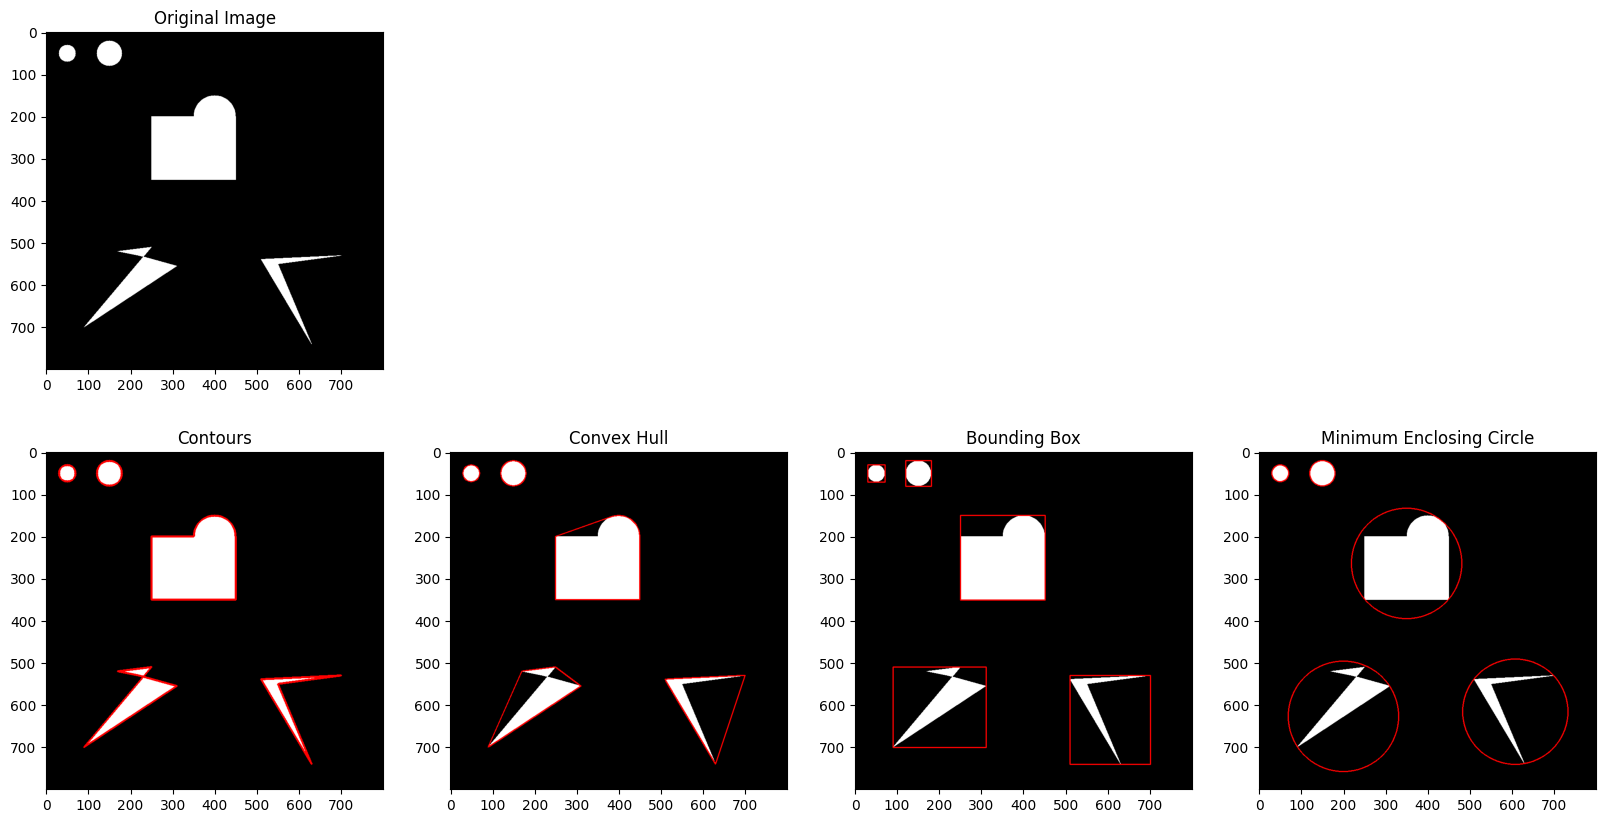

In [ ]:
img = np.zeros((800, 800), dtype=np.uint8)
cv2.circle(img, (50, 50), 20, 255, -1)     # blob 1
cv2.circle(img, (150, 50), 30, 255, -1)    # blob 2

cv2.rectangle(img, (250, 200), (450, 350), 255, -1)   # blob 3
cv2.circle(img, (400, 200), 50, 255, -1)             

pts = np.array([[550,550],[630,740],[510,539],[700,530]], np.int32) # blob 4
pts = pts.reshape((-1,1,2))
cv2.fillPoly(img,[pts],255)

pts = np.array([[310,555],[220,530],[170,520],[250,510],[90,700]], np.int32) # blob 5
pts = pts.reshape((-1,1,2))
cv2.fillPoly(img,[pts],255)

contours, hierarchy = cv2.findContours(img,cv2.RETR_TREE,cv2.CHAIN_APPROX_SIMPLE)

output = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
cnts = output.copy()
convex = output.copy()
box = output.copy()
circle = output.copy()

# cv2.drawContours(image, contours, contourIndex(-1 means all), color, thickness)
cv2.drawContours(cnts, contours, -1, (255, 0, 0), 3)  # Contours

for cnt in contours:
    
    hull = cv2.convexHull(cnt)
    cv2.drawContours(convex, [hull], -1, (255, 0, 0), 2) # Convex Hull

    x, y, w, h = cv2.boundingRect(cnt)
    cv2.rectangle(box, (x, y), (x+w, y+h), (255, 0, 0), 2)   # Bounding Box

    (xc, yc), radius = cv2.minEnclosingCircle(cnt)
    center = (int(xc), int(yc))
    radius = int(radius)
    cv2.circle(circle, center, radius, (255, 0, 0), 2)   # Minimum Enclosing Circle

plt.figure(figsize=[20,10])
plt.subplot(241);plt.imshow(img,cmap='gray');plt.title("Original Image")
plt.subplot(245);plt.imshow(cnts);plt.title("Contours")
plt.subplot(246);plt.imshow(convex);plt.title("Convex Hull")
plt.subplot(247);plt.imshow(box);plt.title("Bounding Box")
plt.subplot(248);plt.imshow(circle);plt.title("Minimum Enclosing Circle")


## Moments & Area
An image moment is a weighted average (or sum) of pixel intensities, often used to describe the shape of an object.

In OpenCV, <code>cv2.moments(contour)</code> computes a set of scalar values that describe geometric properties of the contour.<br>
Key values include:
- <code>m00</code>: The spatial moment, equal to the area of the contour.
- <code>m10</code> and m01: Used to compute the centroid of the contour.

The centroid (center of mass) can be calculated as:<br>
<code>cX = int(M['m10'] / M['m00'])</code><br>
<code>cY = int(M['m01'] / M['m00'])</code>

Area of a Contour is the area is simply the number of pixels inside the contour. 

In OpenCV, <code>cv2.contourArea(contour)</code> computes Area(or m00)

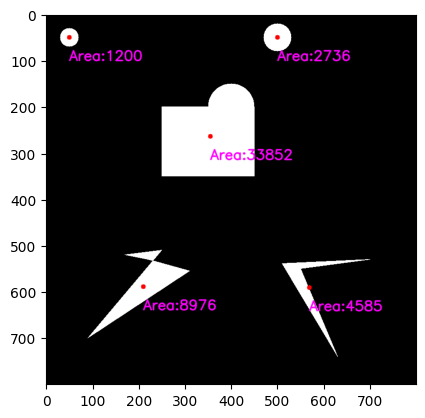

In [ ]:
img = np.zeros((800, 800), dtype=np.uint8)
cv2.circle(img, (50, 50), 20, 255, -1)     # blob 1
cv2.circle(img, (500, 50), 30, 255, -1)    # blob 2

cv2.rectangle(img, (250, 200), (450, 350), 255, -1)   # blob 3
cv2.circle(img, (400, 200), 50, 255, -1)             

pts = np.array([[550,550],[630,740],[510,539],[700,530]], np.int32) # blob 4
pts = pts.reshape((-1,1,2))
cv2.fillPoly(img,[pts],255)

pts = np.array([[310,555],[220,530],[170,520],[250,510],[90,700]], np.int32) # blob 5
pts = pts.reshape((-1,1,2))
cv2.fillPoly(img,[pts],255)

contours, hierarchy = cv2.findContours(img,cv2.RETR_TREE,cv2.CHAIN_APPROX_SIMPLE)
output = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)

for cnt in contours:
    M = cv2.moments(cnt)
    # Centroid
    cX = int(M['m10'] / M['m00'])
    cY = int(M['m01'] / M['m00'])
    cv2.circle(output,(cX,cY),5,(255,0,0),-1) 
    # Area
    area = cv2.contourArea(cnt)
    # area = M['m00'] can also use this
    cv2.putText(output,f"Area:{round(area)}",(cX,cY+50),cv2.FONT_ITALIC,1,(255,0,255),2,cv2.LINE_AA)

plt.imshow(output)



## Approximate
When working with contours, we often get many redundant points along an object’s boundary. To simplify and approximate a shape, OpenCV provides the function <code>cv2.approxPolyDP()</code>.

Function:<br>
<code>approx = cv2.approxPolyDP(contour, epsilon, closed)</code>
- <code>epsilon</code>: Maximum distance between the original curve and its approximation. 
    - Smaller values → closer to original shape.
    - Larger values → simpler approximation.
    - <code>epsilon = percentage * cv2.arcLength(cnt, True)</code> 
- <code>closed</code>: Boolean, True if the approximated curve should be closed.

Key idea: If approx has 3 points → triangle, 4 points → rectangle or square, 5+ points → polygon, and if many points → circle-like shape.

(np.float64(-0.5), np.float64(499.5), np.float64(499.5), np.float64(-0.5))

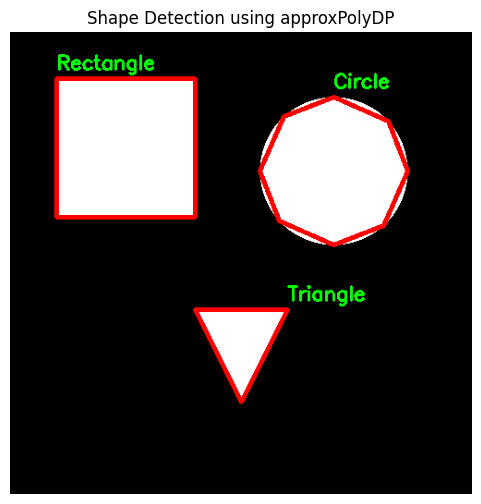

In [43]:
img = np.zeros((500, 500), dtype=np.uint8)

# Draw some shapes
cv2.rectangle(img, (50, 50), (200, 200), 255, -1)  # square
cv2.circle(img, (350, 150), 80, 255, -1)           # circle
pts = np.array([[250,400],[300,300],[200,300]], np.int32)      # triangle
cv2.fillPoly(img, [pts], 255)

contours, _ = cv2.findContours(img,cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
output = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)


for cnt in contours:
    epsilon = 0.02 * cv2.arcLength(cnt, True)   # 2% of perimeter
    approx = cv2.approxPolyDP(cnt, epsilon, True)
    
    # Draw contour
    cv2.drawContours(output, [approx], -1, (0, 0, 255), 3)
    
    # Get shape name based on number of vertices
    vertices = len(approx)
    shape_name = ""
    if vertices == 3:
        shape_name = "Triangle"
    elif vertices == 4:
        shape_name = "Rectangle"
    elif vertices > 6:
        shape_name = "Circle"
    
    # Label the shape
    x,y = approx.ravel()[0], approx.ravel()[1] - 10
    cv2.putText(output, shape_name, (x,y), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0,255,0), 2)


plt.figure(figsize=(6,6))
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB));plt.title("Shape Detection using approxPolyDP");plt.axis("off")

#### Text Bounding Box

Text(0.5, 1.0, 'Bounding Box')

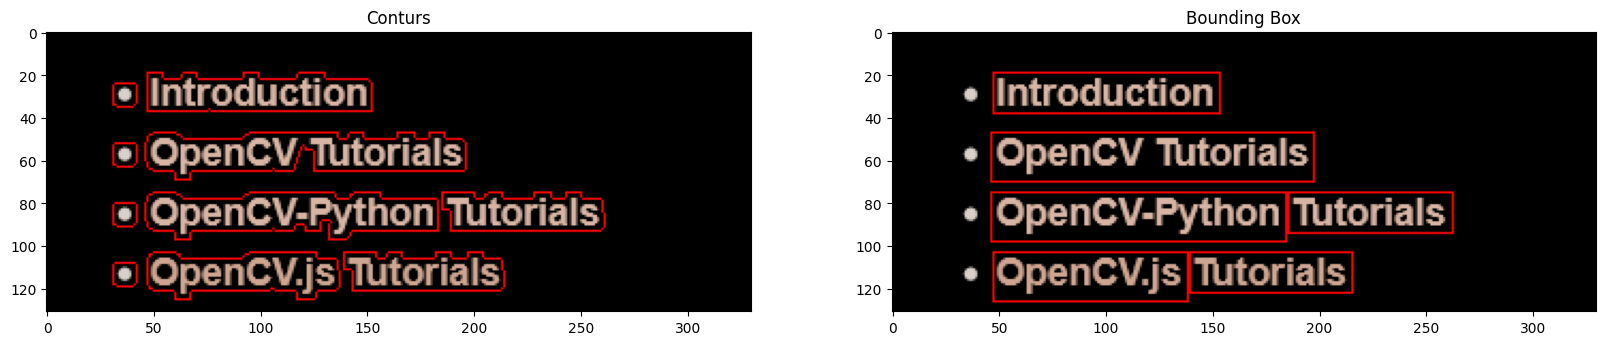

In [71]:
img = cv2.imread("images/text.png")
gray_img = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
_,binary_img = cv2.threshold(gray_img,127,255,cv2.THRESH_BINARY)

kernel = cv2.getStructuringElement(cv2.MORPH_RECT,(7,7))
dilated_img = cv2.dilate(binary_img,kernel,iterations=1)

contours, _ = cv2.findContours(dilated_img,cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
output = img.copy()
cv2.drawContours(output, contours, -1, (255, 0, 0), 1)

box = img.copy()
for cnt in contours:
    # Bounding box 
    x, y, w, h = cv2.boundingRect(cnt)
    area = cv2.contourArea(cnt)
    if area > 500: # exclude dots
        cv2.rectangle(box, (x, y), (x+w, y+h), (255, 0, 0), 1)

plt.figure(figsize=[20,10])
plt.subplot(121);plt.imshow(output);plt.title("Conturs")
plt.subplot(122);plt.imshow(box);plt.title("Bounding Box")